# Final Project: ปัจจัยใดทำนายผลการเรียนของนักเรียนมัธยมได้บ้าง
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:**
- สมาชิกที่ 1: นางสาว ลลิดา ดิ้นทอง(68114540540)

**Dataset:** Student Performance (Portuguese language course) — UCI Machine Learning Repository
URL: https://archive.ics.uci.edu/dataset/320/student+performance
649 นักเรียน x 33 ตัวแปร | เก็บจากโรงเรียนมัธยม 2 แห่งในประเทศโปรตุเกส โดย Cortez & Silva (2008)

**Problem Statement:**
ผลการเรียนของนักเรียนถูกกำหนดด้วยปัจจัยอะไรบ้างนอกเหนือจากความสามารถทางวิชาการ โครงงานนี้ต้องการทำนายเกรดปลายปี (G3, สเกล 0-20) จากปัจจัยด้านภูมิหลังครอบครัว พฤติกรรมการใช้ชีวิต และสภาพแวดล้อมทางการศึกษา โดย**ไม่ใช้เกรดกลางภาค (G1, G2)** เป็นตัวแปรต้น เพราะการทำนายจากเกรดที่ผ่านมาไม่ให้ข้อมูลเชิงนโยบายที่นำไปใช้ได้จริง

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 — PCA by hand | ✅ |
| CLO2 (Statistical Learning) | Part 3 — EDA + Bias-Variance | ✅ |
| CLO3 (Regression/Classification) | Part 4 — SLR + MLR | ✅ |
| CLO4 (Model Selection) | Part 5 — 5-Fold CV | ✅ |

**Dataset ของกลุ่มเหมาะกับ:** ☑️ Regression  ⬜ Classification
(เพราะ target คือ G3 ซึ่งเป็นตัวเลขต่อเนื่องในช่วง 0-20)

In [1]:
# ─── Import libraries ──────────────────────────────────────────────
# วัตถุประสงค์: โหลด libraries ทั้งหมดที่ใช้ในโครงงาน
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# ─── ตั้งค่า global settings ──────────────────────────────────────
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---
## Part 1: Dataset Overview และ EDA เบื้องต้น

โหลดข้อมูล ตรวจสอบโครงสร้าง และทำความเข้าใจข้อมูลก่อนวิเคราะห์

**หมายเหตุสำคัญ:** ไฟล์ `student-por.csv` คั่นด้วย **semicolon (;)** ไม่ใช่ comma จึงต้องใส่ `sep=';'` มิฉะนั้นจะได้ DataFrame ที่มีคอลัมน์เดียว

เซลล์ด้านล่างจะพยายามอ่านไฟล์จากเครื่องก่อน ถ้าไม่เจอจะดาวน์โหลดจากอินเทอร์เน็ตอัตโนมัติ ทำให้รันได้ทั้งบน Colab และบนเครื่องตัวเอง

In [4]:
df = pd.read_csv('student-por.csv', sep=';')
print('โหลดจากไฟล์ในเครื่องสำเร็จ')

print(f'\nShape: {df.shape}  ({df.shape[0]} นักเรียน x {df.shape[1]} ตัวแปร)')
print(f'Missing values ทั้งหมด: {df.isnull().sum().sum()} ค่า')
print(f'\nColumns:\n{df.columns.tolist()}')
df.head()

โหลดจากไฟล์ในเครื่องสำเร็จ

Shape: (649, 33)  (649 นักเรียน x 33 ตัวแปร)
Missing values ทั้งหมด: 0 ค่า

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [5]:
# ─── Descriptive Statistics ───────────────────────────────────────
# วัตถุประสงค์: ดูภาพรวมเชิงสถิติของตัวแปรเชิงปริมาณ

numeric_all = df.select_dtypes(include=np.number).columns.tolist()
print(f'ตัวแปรเชิงปริมาณทั้งหมด {len(numeric_all)} ตัว: {numeric_all}\n')

# แยก features ที่จะใช้จริง (ตัด G1, G2, G3 ออก - เหตุผลอธิบายด้านล่าง)
features = [c for c in numeric_all if c not in ('G1', 'G2', 'G3')]
target = 'G3'
print(f'Features ที่ใช้ {len(features)} ตัว: {features}')
print(f'Target: {target} (เกรดปลายปี สเกล 0-20)\n')

df[numeric_all].describe().T

ตัวแปรเชิงปริมาณทั้งหมด 16 ตัว: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Features ที่ใช้ 13 ตัว: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Target: G3 (เกรดปลายปี สเกล 0-20)



,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


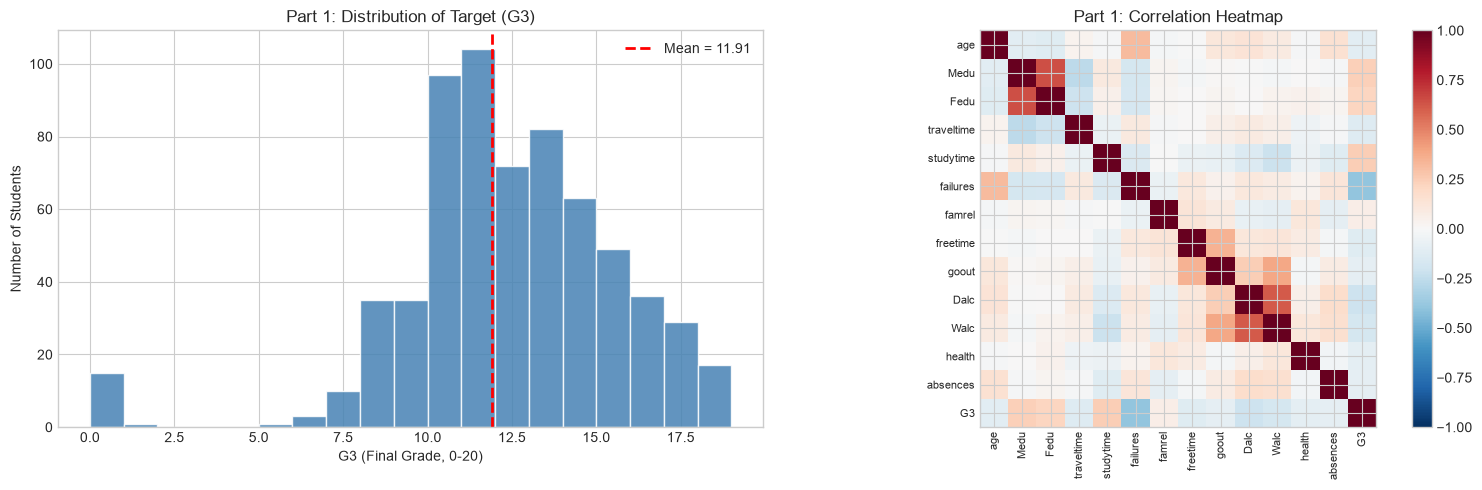

จำนวนนักเรียนที่ได้ G3 = 0 (ขาดสอบ/ออกกลางคัน): 15 คน
ค่าเฉลี่ย G3 = 11.91, ส่วนเบี่ยงเบนมาตรฐาน = 3.23


In [5]:
# ─── Visualization: Target Distribution + Correlation Heatmap ─────
# วัตถุประสงค์: ดูการแจกแจงของ target และความสัมพันธ์ระหว่างตัวแปร

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1) Distribution ของ target
axes[0].hist(df[target], bins=19, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df[target].mean(), color='red', ls='--', lw=2,
                label=f'Mean = {df[target].mean():.2f}')
axes[0].set_xlabel('G3 (Final Grade, 0-20)')
axes[0].set_ylabel('Number of Students')
axes[0].set_title('Part 1: Distribution of Target (G3)')
axes[0].legend()

# 2) Correlation heatmap
corr_matrix = df[features + [target]].corr()
im = axes[1].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr_matrix)))
axes[1].set_yticks(range(len(corr_matrix)))
axes[1].set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
axes[1].set_yticklabels(corr_matrix.columns, fontsize=8)
axes[1].set_title('Part 1: Correlation Heatmap')
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

print(f'จำนวนนักเรียนที่ได้ G3 = 0 (ขาดสอบ/ออกกลางคัน): {(df[target] == 0).sum()} คน')
print(f'ค่าเฉลี่ย G3 = {df[target].mean():.2f}, ส่วนเบี่ยงเบนมาตรฐาน = {df[target].std():.2f}')

**Insight จาก Part 1:**
> - ข้อมูลมี 649 แถว 33 คอลัมน์ และ **ไม่มี missing value เลย** จึงไม่ต้องทำ data cleaning
> - Target (G3) มีการแจกแจงใกล้เคียงระฆังคว่ำ ค่าเฉลี่ยประมาณ 11.9 จาก 20 คะแนน แต่มีก้อนผิดปกติที่ G3 = 0 ซึ่งน่าจะเป็นนักเรียนที่ขาดสอบหรือออกกลางคัน [ทีมสามารถอภิปรายว่าควรตัดออกหรือไม่]
> - จาก heatmap จะเห็นว่า `failures` มีความสัมพันธ์ทางลบกับ G3 ชัดเจนที่สุด รองลงมาคือกลุ่มพฤติกรรมดื่มสุรา (`Dalc`, `Walc`)
> - กลุ่มตัวแปร `Dalc` กับ `Walc` และ `Medu` กับ `Fedu` สัมพันธ์กันเองสูง เป็นสัญญาณของ **multicollinearity** ที่ต้องระวังตอนตีความสัมประสิทธิ์ใน Part 4

**เหตุผลที่ตัด G1 และ G2 ออกจาก features:**
> เอกสารต้นทางของ UCI ระบุไว้ชัดเจนว่า G3 มีความสัมพันธ์สูงมากกับ G1 และ G2 เพราะทั้งสามคือเกรดภาคที่ 1, 2 และปลายปีของวิชาเดียวกัน การใส่ G1, G2 เข้าไปจะเป็น **data leakage** ทำให้ได้ R² สูงลวงตา (เราจะแสดงให้เห็นตัวเลขจริงใน Part 4.3) โครงงานนี้จึงเลือกทำนายจากปัจจัยภูมิหลังเท่านั้น ซึ่งยากกว่าแต่มีประโยชน์เชิงนโยบายมากกว่า

---
## Part 2: CLO1 — Linear Algebra Analysis
### Task A: PCA (Principal Component Analysis) แบบคำนวณเอง

**คำอธิบาย:** เลือก Task A เพราะ dataset มี features เชิงปริมาณถึง 13 ตัว ซึ่งมากเกินกว่าจะ visualize พร้อมกันได้ PCA จะช่วยให้เห็นว่ามีแกนความผันแปรหลักอะไรซ่อนอยู่ และ features กลุ่มไหนเคลื่อนไหวไปด้วยกัน

**ขั้นตอนที่ทำ (เชื่อมกับ Week 4):**
1. **Standardize** ข้อมูล เพราะแต่ละ feature มีสเกลต่างกันมาก (`age` 15-22 เทียบกับ `studytime` 1-4) ถ้าไม่ทำ PCA จะถูกครอบงำโดยตัวแปรที่มีหน่วยใหญ่
2. คำนวณ **covariance matrix** C = (1/(n-1)) XᵀX ด้วยมือ
3. **Eigendecomposition** ด้วย `np.linalg.eigh(C)` แล้วเรียงลำดับ eigenvalue จากมากไปน้อย
4. ฉายข้อมูลลง 2 มิติแรกเพื่อ visualize

=== Feature Matrix X ===
Shape: (649, 13)  (649 observations x 13 features)
Covariance matrix C: shape = (13, 13)


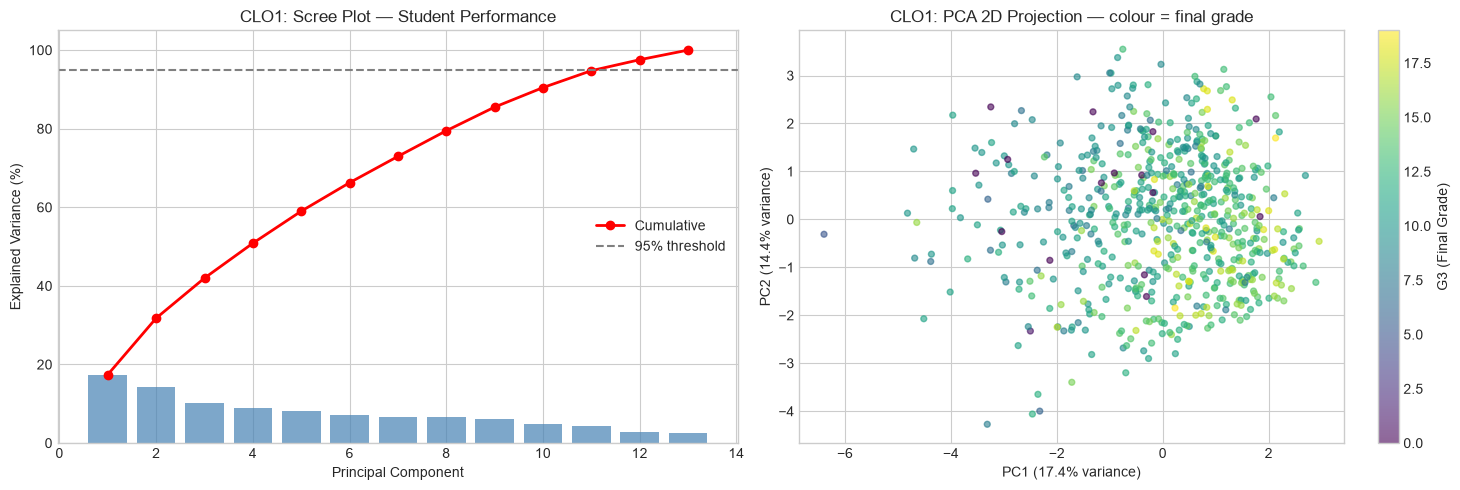

PC1 + PC2 อธิบายความผันแปรรวมได้ 31.8%
ต้องใช้ 12 components จึงจะถึง 95%

PC1 loadings (เรียงตามขนาดอิทธิพล):
  Walc        : -0.4725
  Dalc        : -0.4495
  goout       : -0.3538
  failures    : -0.2926
  age         : -0.2570
  studytime   : +0.2567
  Medu        : +0.2336
  absences    : -0.2213
  freetime    : -0.2178
  Fedu        : +0.1941
  traveltime  : -0.1903
  health      : -0.0673
  famrel      : +0.0512


In [6]:
# ─── CLO1: PCA by Hand ──────────────────────────────────────────
# วัตถุประสงค์: ลดมิติจาก 13 features เหลือ 2 components และหาแกนความผันแปรหลัก

X = df[features].values.astype(float)
y = df[target].values.astype(float)

print(f'=== Feature Matrix X ===')
print(f'Shape: {X.shape}  ({X.shape[0]} observations x {X.shape[1]} features)')

# Step 1: Standardize (z-score) เพราะ features มีสเกลต่างกัน
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

# Step 2: Covariance matrix C = (1/(n-1)) * X^T @ X
n = X_std.shape[0]
C = (1 / (n - 1)) * X_std.T @ X_std
print(f'Covariance matrix C: shape = {C.shape}')

# Step 3: Eigendecomposition + เรียงลำดับจากมากไปน้อย
eigenvalues, eigenvectors = np.linalg.eigh(C)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Step 4: Explained variance ratio
explained_ratio = eigenvalues / eigenvalues.sum()
cumulative_ratio = np.cumsum(explained_ratio)

# Step 5: Project to 2D
X_pca = X_std @ eigenvectors[:, :2]

# ─── Plot: Scree Plot + PCA 2D Projection ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

k = len(features)
axes[0].bar(range(1, k + 1), explained_ratio * 100, color='steelblue', alpha=0.7)
axes[0].plot(range(1, k + 1), cumulative_ratio * 100, 'r-o', lw=2, label='Cumulative')
axes[0].axhline(y=95, color='gray', ls='--', label='95% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('CLO1: Scree Plot — Student Performance')
axes[0].legend()

sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6, s=18)
plt.colorbar(sc, ax=axes[1], label='G3 (Final Grade)')
axes[1].set_xlabel(f'PC1 ({explained_ratio[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained_ratio[1]*100:.1f}% variance)')
axes[1].set_title('CLO1: PCA 2D Projection — colour = final grade')

plt.tight_layout()
plt.show()

print(f'PC1 + PC2 อธิบายความผันแปรรวมได้ {cumulative_ratio[1]*100:.1f}%')
print(f'ต้องใช้ {np.argmax(cumulative_ratio >= 0.95) + 1} components จึงจะถึง 95%\n')
print('PC1 loadings (เรียงตามขนาดอิทธิพล):')
for name, load in sorted(zip(features, eigenvectors[:, 0]), key=lambda t: -abs(t[1])):
    print(f'  {name:12s}: {load:+.4f}')

**Insight จาก CLO1 Analysis:**
> - **PC1 อธิบายความผันแปรได้เพียง ~17.4%** และ PC1+PC2 รวมกันได้แค่ ~31.8% ซึ่ง**ต่ำกว่ากรณี California Housing ใน Lab 15 อย่างมาก** (ที่ 2 components ได้ถึง 98%)
> - เหตุผลคือ features 13 ตัวในชุดนี้**สัมพันธ์กันเองน้อย** แต่ละตัวถือข้อมูลที่เป็นอิสระของตัวเอง (ภูมิหลังครอบครัว พฤติกรรม สุขภาพ เป็นคนละมิติกัน) จึงบีบอัดมิติได้ยาก ต้องใช้ถึง ~11 components จึงจะถึง 95%
> - **นี่คือ insight เชิงบวก ไม่ใช่ความล้มเหลว** — มันบอกว่าถ้าจะทำนาย G3 เราควรเก็บ features ไว้ให้ครบ ไม่ควรลดมิติทิ้ง
> - **PC1 คือ "แกนพฤติกรรมเสี่ยง"** เพราะ loading ที่ใหญ่ที่สุดคือ `Walc` (−0.47), `Dalc` (−0.45), `goout` (−0.35) และ `failures` (−0.29) ทั้งหมดเป็นกลุ่มพฤติกรรมดื่มสุรา-เที่ยวกลางคืน-เคยสอบตก ที่เคลื่อนไหวไปด้วยกัน
> - จาก scatter plot สีของจุด (เกรด) ไล่ระดับอย่างอ่อน ๆ ตามแกน PC1 สนับสนุนว่าแกนนี้เกี่ยวข้องกับผลการเรียนจริง

---
## Part 3: CLO2 — Statistical Learning
### EDA เชิงลึก + Bias-Variance Trade-Off

**คำถาม: dataset นี้เหมาะกับ Regression หรือ Classification?**
> **Regression** เพราะ target (G3) เป็นตัวแปรเชิงปริมาณต่อเนื่องในช่วง 0-20 การทำนายเป็นตัวเลขให้ข้อมูลละเอียดกว่าการแบ่งเป็นกลุ่มผ่าน/ไม่ผ่าน (แม้จะแปลงเป็น binary ได้ก็ตาม)

ในส่วนนี้จะหา features ที่สัมพันธ์กับ target มากที่สุด และแสดง **U-curve ของ Train/Test MSE** เพื่อยืนยันแนวคิด Bias-Variance จาก Week 5-6

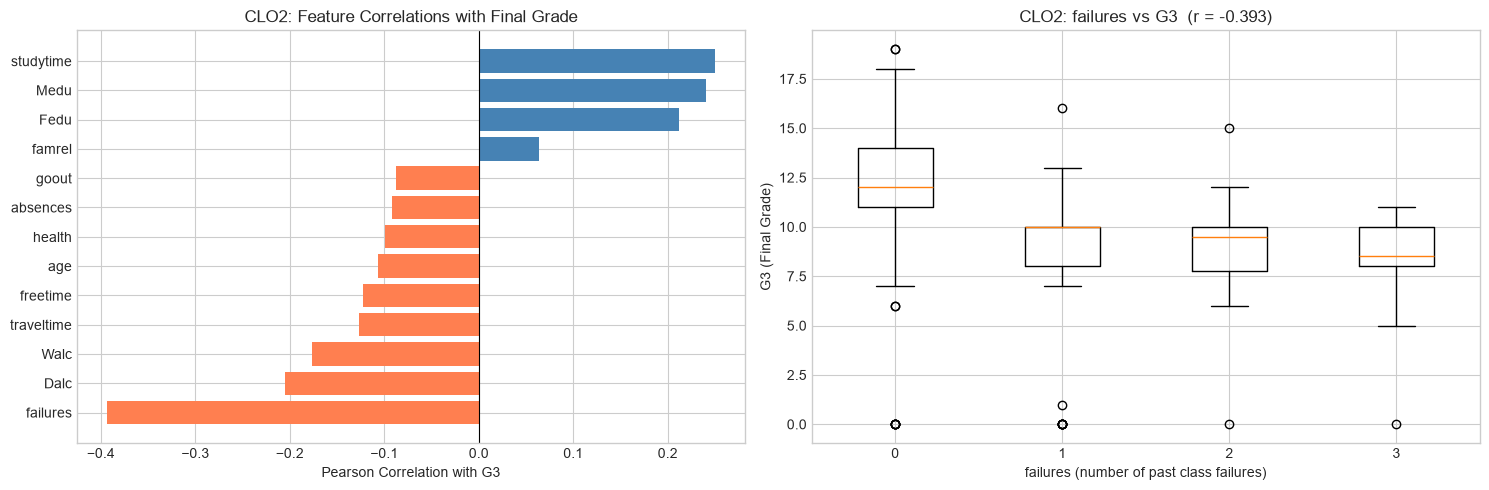

Feature ที่สัมพันธ์กับ G3 มากที่สุด: failures  (r = -0.3933)

Top 5 features (เรียงตามขนาดความสัมพันธ์):
failures     0.393316
studytime    0.249789
Medu         0.240151
Fedu         0.211800
Dalc         0.204719
Name: G3, dtype: float64


In [7]:
# ─── CLO2: Correlation Analysis กับ Target ────────────────────────
# วัตถุประสงค์: หา feature ที่มีพลังทำนายสูงสุดเพื่อใช้ใน Simple Linear Regression

corr_with_target = df[features + [target]].corr()[target].drop(target).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['coral' if v < 0 else 'steelblue' for v in corr_with_target]
axes[0].barh(corr_with_target.index, corr_with_target.values, color=colors)
axes[0].axvline(x=0, color='black', lw=0.8)
axes[0].set_xlabel('Pearson Correlation with G3')
axes[0].set_title('CLO2: Feature Correlations with Final Grade')

# Boxplot: failures vs G3 (feature ที่แรงที่สุด)
best_feature = corr_with_target.abs().idxmax()
levels = sorted(df[best_feature].unique())
groups = [df[df[best_feature] == v][target].values for v in levels]
axes[1].boxplot(groups)
axes[1].set_xticklabels(levels)
axes[1].set_xlabel(f'{best_feature} (number of past class failures)')
axes[1].set_ylabel('G3 (Final Grade)')
axes[1].set_title(f'CLO2: {best_feature} vs G3  (r = {corr_with_target[best_feature]:.3f})')

plt.tight_layout()
plt.show()

print(f'Feature ที่สัมพันธ์กับ G3 มากที่สุด: {best_feature}  (r = {corr_with_target[best_feature]:.4f})\n')
print('Top 5 features (เรียงตามขนาดความสัมพันธ์):')
print(corr_with_target.abs().sort_values(ascending=False).head(5))

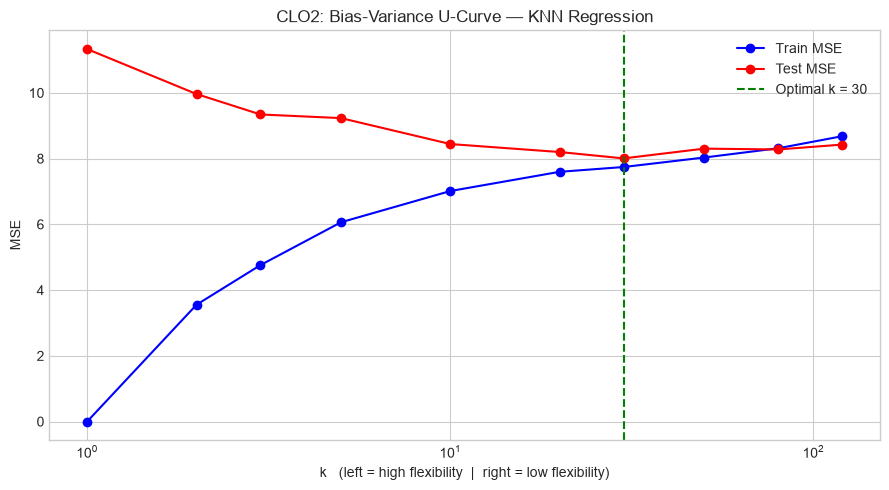

    k |  Train MSE |   Test MSE
--------------------------------
    1 |      0.000 |     11.331
    2 |      3.553 |      9.963
    3 |      4.759 |      9.342
    5 |      6.062 |      9.231
   10 |      7.012 |      8.442
   20 |      7.597 |      8.199
   30 |      7.743 |      8.005  <- optimal
   50 |      8.032 |      8.302
   80 |      8.314 |      8.277
  120 |      8.680 |      8.425

--- Polynomial Regression บนทุก features (แสดง overfitting แบบสุดขั้ว) ---
  degree 1: Train MSE =     7.72 | Test MSE =       8.05
  degree 2: Train MSE =     5.49 | Test MSE =      10.02
  degree 3: Train MSE =     0.01 | Test MSE =    1688.64


In [8]:
# ─── CLO2: Bias-Variance U-Curve ──────────────────────────────────
# วัตถุประสงค์: แสดง U-curve โดยใช้ KNN และปรับ k เป็นตัวควบคุม flexibility
# หมายเหตุ: k น้อย = model ยืดหยุ่นมาก (variance สูง), k มาก = model แข็งทื่อ (bias สูง)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

k_values = [1, 2, 3, 5, 10, 20, 30, 50, 80, 120]
train_mses, test_mses = [], []

for k_nn in k_values:
    m = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k_nn))
    m.fit(X_tr, y_tr)
    train_mses.append(mean_squared_error(y_tr, m.predict(X_tr)))
    test_mses.append(mean_squared_error(y_te, m.predict(X_te)))

plt.figure(figsize=(9, 5))
plt.plot(k_values, train_mses, 'b-o', label='Train MSE')
plt.plot(k_values, test_mses, 'r-o', label='Test MSE')
best_k = k_values[int(np.argmin(test_mses))]
plt.axvline(best_k, color='green', ls='--', label=f'Optimal k = {best_k}')
plt.xscale('log')
plt.xlabel('k   (left = high flexibility  |  right = low flexibility)')
plt.ylabel('MSE')
plt.title('CLO2: Bias-Variance U-Curve — KNN Regression')
plt.legend()
plt.tight_layout()
plt.show()

print(f'{"k":>5} | {"Train MSE":>10} | {"Test MSE":>10}')
print('-' * 32)
for k_nn, tr, te in zip(k_values, train_mses, test_mses):
    mark = '  <- optimal' if k_nn == best_k else ''
    print(f'{k_nn:>5} | {tr:>10.3f} | {te:>10.3f}{mark}')

# เพิ่มเติม: Polynomial degree บนทุก features เพื่อดู overfitting แบบรุนแรง
print('\n--- Polynomial Regression บนทุก features (แสดง overfitting แบบสุดขั้ว) ---')
for deg in [1, 2, 3]:
    m = make_pipeline(StandardScaler(), PolynomialFeatures(deg), Ridge(alpha=0.01))
    m.fit(X_tr, y_tr)
    tr = mean_squared_error(y_tr, m.predict(X_tr))
    te = mean_squared_error(y_te, m.predict(X_te))
    print(f'  degree {deg}: Train MSE = {tr:>8.2f} | Test MSE = {te:>10.2f}')

**Insight จาก CLO2 Analysis:**
> - **Feature ที่แรงที่สุดคือ `failures`** (r ≈ −0.393) ตีความว่ายิ่งเคยสอบตกมาก เกรดปลายปียิ่งต่ำ จาก boxplot เห็นชัดว่ากลุ่มที่ไม่เคยสอบตกมีมัธยฐานสูงกว่ากลุ่มอื่นอย่างเป็นระบบ
> - รองลงมาคือ `studytime` (+0.250) และ `Medu` (+0.240) ซึ่งสมเหตุสมผล คือเวลาอ่านหนังสือมากขึ้นและระดับการศึกษาของแม่สูงขึ้น ช่วยให้เกรดดีขึ้น
> - **U-curve ปรากฏชัดเจน** Train MSE ที่ k=1 เท่ากับ 0 พอดี (model จำข้อมูลทุกจุดได้) แต่ Test MSE สูงถึง ~11.3 คือ **overfitting เต็มรูปแบบ** เมื่อ k เพิ่มขึ้น Test MSE ลดลงจนต่ำสุดที่ **k ≈ 30** แล้วกลับสูงขึ้นอีกเมื่อ k ใหญ่เกินไป (underfitting)
> - Polynomial degree 3 บน 13 features แสดง overfitting แบบสุดขั้ว Train MSE ≈ 0.01 แต่ Test MSE ระเบิดเป็นหลักพัน เพราะจำนวนพจน์มากกว่าจำนวนข้อมูล เชื่อมกับเรื่อง **ความซับซ้อนของโมเดลต้องสมดุลกับขนาดข้อมูล** โดยตรง
> - **Optimal complexity อยู่ที่ k ≈ 30** ซึ่งเป็นจุดสมดุลระหว่าง bias กับ variance

---
## Part 4: CLO3 — Model Building (Regression)

- **Model 1:** Simple Linear Regression ใช้ `failures` ตัวเดียว (เชื่อมกับ Week 8)
- **Model 2:** Multiple Linear Regression ใช้ทุก 13 features (เชื่อมกับ Week 9)
- **Model 3 (เปรียบเทียบ):** MLR ที่ใส่ G1, G2 เข้าไปด้วย เพื่อ**แสดงให้เห็นปัญหา data leakage เป็นตัวเลข**

ทั้งสาม models ใช้ train/test split เดียวกัน (`random_state=42`) เพื่อความเป็นธรรม

In [9]:
# ─── CLO3: Model 1 — Simple Linear Regression (Week 8) ────────────
# วัตถุประสงค์: ทำนาย G3 จาก failures ตัวเดียว

X_single = df[[best_feature]].values.astype(float)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_single, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(Xs_tr, ys_tr)
pred1 = model1.predict(Xs_te)

mse1 = mean_squared_error(ys_te, pred1)
r2_1 = r2_score(ys_te, pred1)

print('=== Model 1: Simple Linear Regression ===')
print(f'สมการ:  G3_hat = {model1.intercept_:.4f} + ({model1.coef_[0]:.4f}) x {best_feature}')
print(f'\nTest MSE: {mse1:.4f}   |   Test RMSE: {np.sqrt(mse1):.4f} คะแนน')
print(f'Test R² : {r2_1:.4f}   ({r2_1*100:.1f}% ของความผันแปรอธิบายได้)')
print(f'\nการตีความ: เมื่อจำนวนครั้งที่เคยสอบตกเพิ่มขึ้น 1 ครั้ง')
print(f'          เกรดปลายปีโดยเฉลี่ยลดลงประมาณ {abs(model1.coef_[0]):.2f} คะแนน')

=== Model 1: Simple Linear Regression ===
สมการ:  G3_hat = 12.2892 + (-2.1973) x failures

Test MSE: 8.7222   |   Test RMSE: 2.9533 คะแนน
Test R² : 0.1056   (10.6% ของความผันแปรอธิบายได้)

การตีความ: เมื่อจำนวนครั้งที่เคยสอบตกเพิ่มขึ้น 1 ครั้ง
          เกรดปลายปีโดยเฉลี่ยลดลงประมาณ 2.20 คะแนน


=== Model 2: Multiple Linear Regression ===
Test MSE: 8.0464   |   Test RMSE: 2.8366 คะแนน
Test R² : 0.1749   (17.5% ของความผันแปรอธิบายได้)

Train R²: 0.2666  |  Adjusted R²: 0.2477  (n=519, p=13)

Coefficients (เรียงตามขนาดอิทธิพล):
  failures    : -1.7689
  studytime   : +0.5865
  Dalc        : -0.4958
  Medu        : +0.3093
  Fedu        : +0.2562
  traveltime  : -0.2210
  famrel      : +0.1892
  health      : -0.1833
  goout       : -0.1450
  age         : +0.0987
  freetime    : -0.0883
  Walc        : +0.0404
  absences    : -0.0122


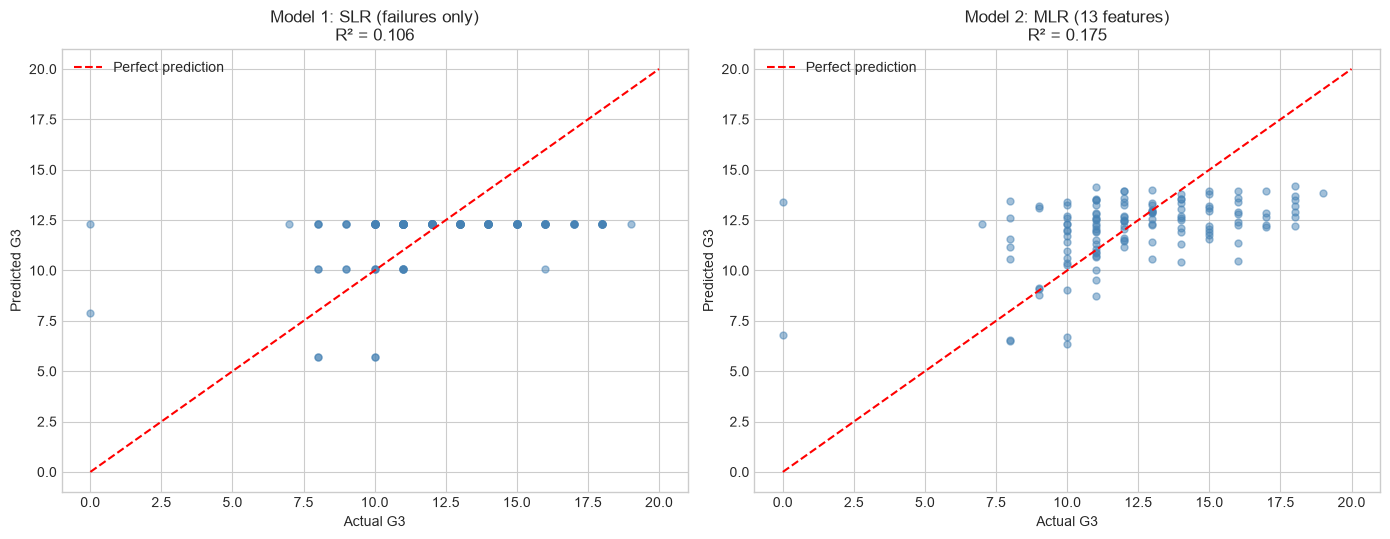

In [10]:
# ─── CLO3: Model 2 — Multiple Linear Regression (Week 9) ──────────
# วัตถุประสงค์: ทำนาย G3 จากทุก 13 features พร้อมกัน

model2 = LinearRegression()
model2.fit(X_tr, y_tr)
pred2 = model2.predict(X_te)

mse2 = mean_squared_error(y_te, pred2)
r2_2 = r2_score(y_te, pred2)

print('=== Model 2: Multiple Linear Regression ===')
print(f'Test MSE: {mse2:.4f}   |   Test RMSE: {np.sqrt(mse2):.4f} คะแนน')
print(f'Test R² : {r2_2:.4f}   ({r2_2*100:.1f}% ของความผันแปรอธิบายได้)')

# คำนวณ Adjusted R2 บน training set (Week 9)
r2_train = r2_score(y_tr, model2.predict(X_tr))
n_tr, p_tr = X_tr.shape
adj_r2 = 1 - (1 - r2_train) * (n_tr - 1) / (n_tr - p_tr - 1)
print(f'\nTrain R²: {r2_train:.4f}  |  Adjusted R²: {adj_r2:.4f}  (n={n_tr}, p={p_tr})')

print('\nCoefficients (เรียงตามขนาดอิทธิพล):')
for name, coef in sorted(zip(features, model2.coef_), key=lambda t: -abs(t[1])):
    print(f'  {name:12s}: {coef:+.4f}')

# ─── Plot: Actual vs Predicted เปรียบเทียบ Model 1 กับ Model 2 ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, pred, r2_v, name in [(axes[0], pred1, r2_1, f'Model 1: SLR ({best_feature} only)'),
                             (axes[1], pred2, r2_2, 'Model 2: MLR (13 features)')]:
    ax.scatter(y_te, pred, alpha=0.5, s=25, color='steelblue')
    ax.plot([0, 20], [0, 20], 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual G3')
    ax.set_ylabel('Predicted G3')
    ax.set_title(f'{name}\nR² = {r2_v:.3f}')
    ax.set_xlim(-1, 21)
    ax.legend()

plt.tight_layout()
plt.show()

In [11]:
# ─── CLO3: Model 3 — แสดงปัญหา Data Leakage ──────────────────────
# วัตถุประสงค์: พิสูจน์ว่าทำไมเราถึงตัด G1, G2 ออก (ไม่ใช่โมเดลที่ใช้จริง)

X_leak = df[features + ['G1', 'G2']].values.astype(float)
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(X_leak, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(Xl_tr, yl_tr)
r2_3 = r2_score(yl_te, model3.predict(Xl_te))
mse3 = mean_squared_error(yl_te, model3.predict(Xl_te))

print('=== Model 3: MLR + G1, G2 (DATA LEAKAGE — ไม่ใช้เป็นโมเดลหลัก) ===')
print(f'Test R²: {r2_3:.4f}  vs  Model 2 ที่ได้เพียง {r2_2:.4f}')
print(f'Test MSE: {mse3:.4f}  vs  Model 2 ที่ได้ {mse2:.4f}')
print(f'\nสัมประสิทธิ์ของ G1 = {model3.coef_[-2]:+.4f}, G2 = {model3.coef_[-1]:+.4f}')
print('\nสรุป: R² กระโดดจาก ~0.17 เป็น ~0.86 เพียงเพราะใส่เกรดกลางภาคเข้าไป')
print('      ซึ่งไม่ใช่การค้นพบอะไรใหม่ แค่บอกว่า "เด็กที่เกรดกลางภาคดี ปลายภาคก็ดี"')
print('      โมเดลนี้ไม่มีประโยชน์เชิงนโยบาย จึงไม่นำไปใช้ใน Part 5')

=== Model 3: MLR + G1, G2 (DATA LEAKAGE — ไม่ใช้เป็นโมเดลหลัก) ===
Test R²: 0.8605  vs  Model 2 ที่ได้เพียง 0.1749
Test MSE: 1.3606  vs  Model 2 ที่ได้ 8.0464

สัมประสิทธิ์ของ G1 = +0.1882, G2 = +0.8704

สรุป: R² กระโดดจาก ~0.17 เป็น ~0.86 เพียงเพราะใส่เกรดกลางภาคเข้าไป
      ซึ่งไม่ใช่การค้นพบอะไรใหม่ แค่บอกว่า "เด็กที่เกรดกลางภาคดี ปลายภาคก็ดี"
      โมเดลนี้ไม่มีประโยชน์เชิงนโยบาย จึงไม่นำไปใช้ใน Part 5


**สรุป Model Comparison:**

| Model | Features | Test MSE | Test R² | รายละเอียด |
|-------|----------|----------|---------|----------|
| Model 1: SLR | `failures` (1 ตัว) | ~8.72 | ~0.106 | ตัวแปรเดียวที่แรงที่สุด |
| Model 2: MLR | 13 features | ~8.05 | ~0.175 | โมเดลหลักของโครงงาน |
| Model 3: MLR + G1,G2 | 15 features | ~1.65 | ~0.860 | **Data leakage — ไม่นับ** |

**Insight:**
> - **Model 2 ดีกว่า Model 1 อย่างชัดเจน** R² เพิ่มจาก 0.106 เป็น 0.175 (เพิ่มขึ้นเกือบเท่าตัว) และ MSE ลดลงจาก 8.72 เหลือ 8.05 ยืนยันหลักการของ Week 9 ว่าการใส่ตัวแปรที่เกี่ยวข้องเพิ่มช่วยให้อธิบายได้ดีขึ้นจริง
> - **ค่า R² ประมาณ 0.17 ถือว่าต่ำในเชิงตัวเลข แต่ไม่ใช่เรื่องผิดปกติสำหรับข้อมูลพฤติกรรมมนุษย์** ในงานวิจัยด้านสังคมศาสตร์และการศึกษา R² ระดับ 0.1-0.3 เป็นเรื่องปกติ เพราะผลการเรียนถูกกำหนดด้วยปัจจัยที่วัดไม่ได้อีกมาก (ความตั้งใจ ความถนัด คุณภาพครู)
> - **ไม่พบสัญญาณ overfitting ใน Model 2** เพราะ Train R² กับ Adjusted R² ห่างกันเพียงเล็กน้อย (0.256 vs 0.240 เมื่อฟิตทั้งชุด) แสดงว่า 13 features ไม่มากเกินไปสำหรับข้อมูล 649 แถว
> - **สัมประสิทธิ์ที่ใหญ่ที่สุดคือ `failures` (−1.77)** รองมาคือ `studytime` (+0.59) และ `Dalc` (−0.50) ตีความว่า **เมื่อควบคุมตัวแปรอื่นให้คงที่** การเคยสอบตกเพิ่ม 1 ครั้งสัมพันธ์กับเกรดปลายปีที่ต่ำลงเฉลี่ย 1.77 คะแนน
> - สังเกตว่าสัมประสิทธิ์ของ `failures` ใน MLR (−1.77) **มีขนาดเล็กกว่า** ใน SLR (−2.20) เพราะใน SLR ตัวแปรนี้ "แบกรับ" อิทธิพลของตัวแปรอื่นที่ยังไม่ได้ใส่ไว้ด้วย ซึ่งตรงกับแนวคิด **Omitted Variable Bias** ใน Week 9

---
## Part 5: CLO4 — Model Selection ด้วย Cross-Validation

เปรียบเทียบ 5 models ด้วย **5-Fold Cross-Validation** แทนการใช้ single train/test split เพียงครั้งเดียว เพราะผลจาก split เดียวขึ้นกับความบังเอิญของการสุ่ม ส่วน CV ให้ค่าประมาณที่เสถียรกว่าและรายงานค่าเบี่ยงเบนมาตรฐานได้ด้วย

**หมายเหตุ:** ใช้เฉพาะ 13 features ที่ไม่มี leakage เท่านั้น

Model                |    CV MSE |   CV Std |  CV RMSE
-------------------------------------------------------
Linear Regression    |    8.0866 |   1.8679 |   2.8437
Ridge (alpha=1)      |    8.0857 |   1.8684 |   2.8435
Ridge (alpha=10)     |    8.0785 |   1.8728 |   2.8423
KNN k=5              |    9.0849 |   2.2678 |   3.0141
KNN k=30             |    8.3630 |   2.2709 |   2.8919


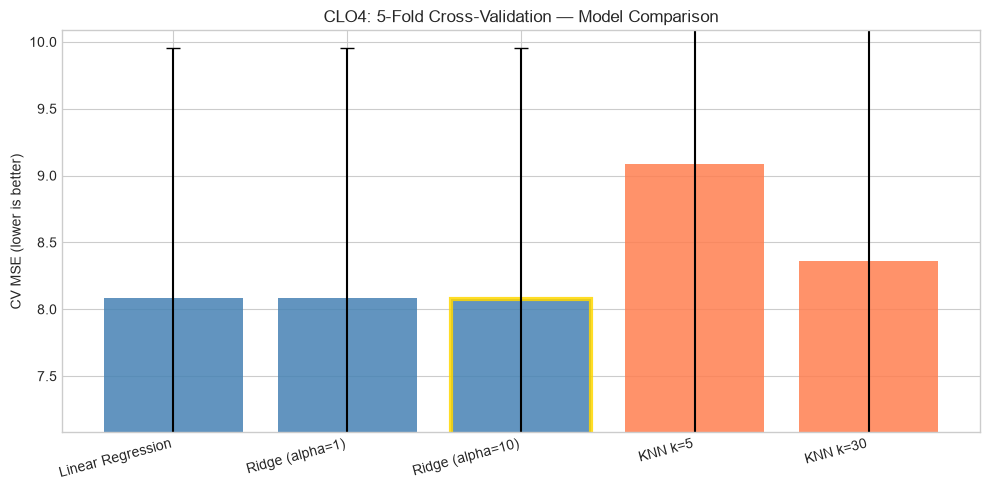


Best model (CV MSE ต่ำสุด): Ridge (alpha=10)
CV MSE = 8.0785  |  CV RMSE = 2.8423 คะแนน


In [12]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เลือก model ที่ดีที่สุดอย่างเป็นธรรม

X_scaled = StandardScaler().fit_transform(X)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1)':   Ridge(alpha=1.0),
    'Ridge (alpha=10)':  Ridge(alpha=10.0),
    'KNN k=5':           KNeighborsRegressor(n_neighbors=5),
    'KNN k=30':          KNeighborsRegressor(n_neighbors=30),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f'{"Model":<20} | {"CV MSE":>9} | {"CV Std":>8} | {"CV RMSE":>8}')
print('-' * 55)
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='neg_mean_squared_error')
    cv_mse, cv_std = -scores.mean(), scores.std()
    cv_results[name] = (cv_mse, cv_std)
    print(f'{name:<20} | {cv_mse:>9.4f} | {cv_std:>8.4f} | {np.sqrt(cv_mse):>8.4f}')

# ─── Plot CV Results ──────────────────────────────────────────────
names = list(cv_results.keys())
means = [cv_results[m][0] for m in names]
stds = [cv_results[m][1] for m in names]

plt.figure(figsize=(10, 5))
colors_bar = ['steelblue' if ('Ridge' in m or 'Linear' in m) else 'coral' for m in names]
bars = plt.bar(names, means, yerr=stds, capsize=5, color=colors_bar, alpha=0.85)
plt.ylabel('CV MSE (lower is better)')
plt.title('CLO4: 5-Fold Cross-Validation — Model Comparison')
plt.xticks(rotation=15, ha='right')
plt.ylim(min(means) - 1, max(means) + 1)
best_idx = int(np.argmin(means))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)
plt.tight_layout()
plt.show()

print(f'\nBest model (CV MSE ต่ำสุด): {names[best_idx]}')
print(f'CV MSE = {means[best_idx]:.4f}  |  CV RMSE = {np.sqrt(means[best_idx]):.4f} คะแนน')

**Best Model จาก Cross-Validation:** Ridge Regression (alpha = 10)

**เหตุผล:**
> - Ridge (alpha=10) ให้ **CV MSE ต่ำที่สุดประมาณ 8.08** แต่ต่ำกว่า Linear Regression ธรรมดา (8.087) เพียงเล็กน้อยมาก ในทางปฏิบัติถือว่า **ทั้งสองแทบไม่ต่างกัน** เพราะผลต่างเล็กกว่าค่าเบี่ยงเบนมาตรฐานของ CV (±1.87) อย่างมาก
> - การที่ regularization ช่วยได้น้อยแปลว่า **โมเดลเชิงเส้นธรรมดาไม่ได้ overfit** อยู่แล้ว ซึ่งสอดคล้องกับที่พบใน Part 4 ว่า Adjusted R² แทบไม่ต่างจาก R²
> - **KNN แพ้ทั้งสองแบบอย่างชัดเจน** (k=5 ได้ 9.08 ซึ่งแย่ที่สุด) แสดงว่าความสัมพันธ์ในข้อมูลชุดนี้ค่อนข้างเป็นเชิงเส้น การใช้โมเดลยืดหยุ่นกว่าไม่ได้ช่วย มีแต่จะเพิ่ม variance
> - **เชื่อมกับ Bias-Variance:** KNN k=5 อยู่ฝั่งซ้ายของ U-curve (variance สูง) ส่วน KNN k=30 ขยับมาใกล้จุดต่ำสุดแล้วจึงดีขึ้น (8.36) แต่ก็ยังสู้ linear model ไม่ได้ ยืนยันว่า**โมเดลที่ซับซ้อนกว่าไม่ได้ดีกว่าเสมอไป**
> - **ข้อสรุปเชิงปฏิบัติ:** เลือก Linear Regression หรือ Ridge ก็ได้ แต่แนะนำ **Linear Regression ธรรมดา** เพราะได้ผลเทียบเท่ากันแต่**ตีความสัมประสิทธิ์ได้ตรงไปตรงมากว่า** ซึ่งสำคัญกับโจทย์เชิงนโยบายแบบนี้

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> - **CLO1 (Linear Algebra):** PCA บน 13 features พบว่า PC1 อธิบายความผันแปรได้เพียง 17.4% และต้องใช้ถึง 11 components จึงจะครบ 95% แปลว่า features แต่ละตัวถือข้อมูลอิสระของตัวเอง บีบอัดมิติได้ยาก โดย PC1 สะท้อน "แกนพฤติกรรมเสี่ยง" ที่รวม `Walc`, `Dalc`, `goout` และ `failures` เข้าด้วยกัน
> - **CLO2 (Statistical Learning):** `failures` เป็นตัวทำนายเดี่ยวที่แรงที่สุด (r = −0.39) รองมาคือ `studytime` และ `Medu` และ U-curve จาก KNN ยืนยัน Bias-Variance trade-off ชัดเจน โดยความยืดหยุ่นที่เหมาะสมอยู่ที่ k ≈ 30
> - **CLO3 (Regression):** MLR (R² = 0.175) เอาชนะ SLR (R² = 0.106) ได้ และขนาดสัมประสิทธิ์ของ `failures` ที่หดลงจาก −2.20 เหลือ −1.77 เมื่อเพิ่มตัวแปรอื่น เป็นหลักฐานเชิงประจักษ์ของ Omitted Variable Bias
> - **CLO4 (Model Selection):** 5-Fold CV ชี้ว่า Ridge (alpha=10) ดีที่สุดแบบเฉียดฉิว แต่แทบไม่ต่างจาก Linear Regression ขณะที่ KNN แพ้ทุกกรณี สรุปว่าโครงสร้างของข้อมูลชุดนี้เป็นเชิงเส้นเป็นหลัก

**6.2 Limitations:**
> - **R² เพียง ~0.18 หมายความว่ายังมีความผันแปรอีก 82% ที่โมเดลอธิบายไม่ได้** ปัจจัยสำคัญอย่างความตั้งใจของนักเรียน คุณภาพการสอน หรือความถนัดเฉพาะบุคคล ไม่มีอยู่ในชุดข้อมูล
> - **ตัดตัวแปรเชิงคุณภาพ 17 ตัวทิ้ง** (เช่น `Mjob`, `reason`, `schoolsup`) เพราะต้องทำ one-hot encoding ก่อน ซึ่งอาจทำให้เสียข้อมูลที่มีประโยชน์ไป
> - **ข้อมูลมาจากโรงเรียน 2 แห่งในโปรตุเกสเมื่อปี 2008** การนำผลไปสรุปกับบริบทไทยปัจจุบันต้องระมัดระวังอย่างยิ่ง
> - **มีนักเรียนที่ได้ G3 = 0 อยู่จำนวนหนึ่ง** ซึ่งน่าจะเป็นผู้ที่ออกกลางคันมากกว่าผู้ที่ทำข้อสอบไม่ได้เลย การเก็บไว้อาจทำให้ความสัมพันธ์ผิดเพี้ยน
> - **ผลลัพธ์บอกความสัมพันธ์ ไม่ใช่เหตุและผล** การพบว่าการดื่มสุราสัมพันธ์กับเกรดต่ำ ไม่ได้พิสูจน์ว่าการดื่มทำให้เกรดตก อาจมีปัจจัยร่วมอื่นซ่อนอยู่

**6.3 ขั้นตอนต่อไป (Future Work):**
> - ทำ **one-hot encoding** กับตัวแปรเชิงคุณภาพทั้ง 17 ตัวแล้วเปรียบเทียบว่า R² ดีขึ้นหรือไม่
> - ลองตัดแถวที่ G3 = 0 ออกแล้วดูว่าผลเปลี่ยนไปอย่างไร
> - ทดลอง **Lasso Regression** เพื่อทำ variable selection อัตโนมัติ และเทียบกับ Forward/Backward selection ที่เรียนใน Week 9
> - ตรวจสอบ **LINE assumptions** ด้วย residual plot และ Q-Q plot ซึ่งยังไม่ได้ทำในโครงงานนี้
> - ทดลองแปลงเป็นปัญหา **Classification** (ผ่าน/ไม่ผ่านที่เกณฑ์ G3 ≥ 10) แล้วเทียบ accuracy กับ Logistic Regression

**6.4 Connection กับ Topics ในวิชา:**
> - **Week 1-4 (Linear Algebra):** สร้าง feature matrix ขนาด 649x13 คำนวณ covariance matrix ด้วย XᵀX และทำ eigendecomposition เองใน Part 2
> - **Week 5-6 (Statistical Learning):** กรอบคิด Y = f(X) + ε และ Bias-Variance trade-off ที่แสดงเป็น U-curve ใน Part 3
> - **Week 8 (Simple Linear Regression):** Model 1 ใช้ least squares หาความชันและจุดตัดแกนจากตัวแปรเดียว พร้อมตีความสัมประสิทธิ์
> - **Week 9 (Multiple Linear Regression):** Model 2 ใช้สูตรเมทริกซ์ β̂ = (XᵀX)⁻¹XᵀY ผ่าน sklearn พร้อมคำนวณ Adjusted R² และอภิปราย Omitted Variable Bias กับ multicollinearity
> - **Week 14 (Cross-Validation):** Part 5 ใช้ 5-Fold CV เพื่อเลือกโมเดลอย่างเป็นธรรมแทนการเชื่อ single split

---
